
Training MLP with MAE loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0860 - val_loss: 0.0639
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0610 - val_loss: 0.0621
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0622 - val_loss: 0.0608
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0540 - val_loss: 0.0604
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0548 - val_loss: 0.0606
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0529 - val_loss: 0.0610
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0496 - val_loss: 0.0627
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0492 - val_loss: 0.0625
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0532 - val_loss: 0.0611
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 4.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


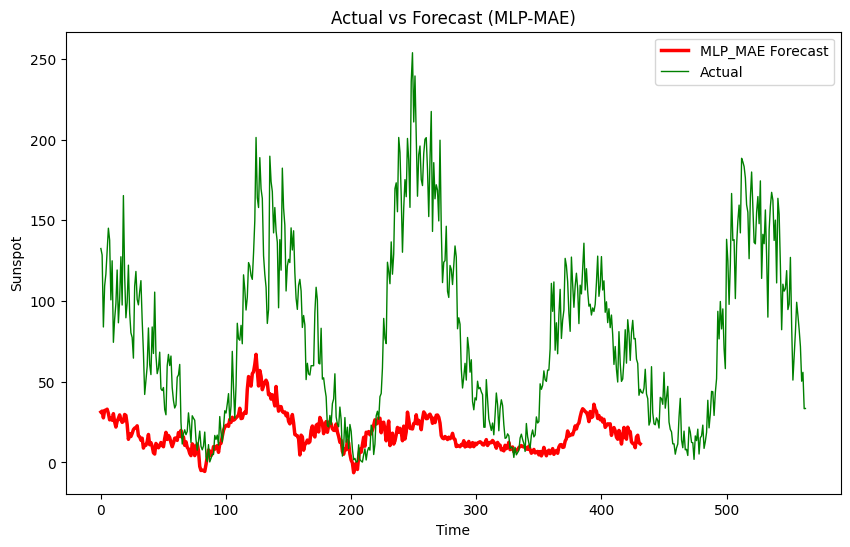


Evaluation Metrics
MSE   : 6212.866424815388
RMSE  : 78.8217382757789
NRMSE: 0.31081127080354454
MAE   : 62.43586249494002
SMAPE : 114.07538968095584
MASE  : 4.21619376973273


In [3]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 3. TRAIN MODEL (MAE LOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP with MAE loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=tf.keras.losses.MeanAbsoluteError()
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 4. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)
    model = tf.keras.models.load_model(cfg['model_path'])

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 5. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)
    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 6. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_MAE Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-MAE)")
    plt.legend()
    plt.show()


# =========================================================
# 7. METRICS
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 8. CONFIGURATION (ALL PATHS FILLED)
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_30\x_train_sunspot_full_30.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_30\y_train_sunspot_full_30.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV (FOR INVERSE SCALING + PLOT)
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_mae_sunspot_final_30.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_mae_daily_sunspot_loss_history_30.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mae_sunspot_30.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mae_sunspot_30.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mae_sunspot_rescaled_30.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mae_sunspot_rescaled_30.csv"
}


# =========================================================
# 9. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP with MSE loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0167 - val_loss: 0.0152
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0116 - val_loss: 0.0149
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0094 - val_loss: 0.0157
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0078 - val_loss: 0.0155
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0073 - val_loss: 0.0165
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0076 - val_loss: 0.0160
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0060 - val_loss: 0.0162
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


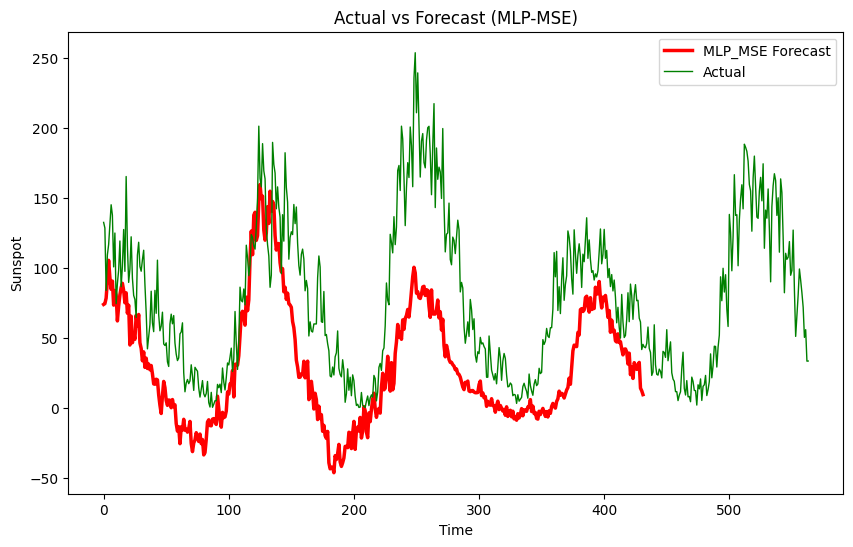


Evaluation Metrics
MSE   : 3451.348379556348
RMSE  : 58.748177670089035
NRMSE: 0.23165685201139208
MAE   : 49.75245409516868
SMAPE : 120.49118145213032
MASE  : 3.3597035197834235


In [5]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 3. TRAIN MODEL (MSE LOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP with MSE loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=tf.keras.losses.MeanSquaredError()
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 4. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)
    model = tf.keras.models.load_model(cfg['model_path'])

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 5. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)
    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 6. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_MSE Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-MSE)")
    plt.legend()
    plt.show()


# =========================================================
# 7. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 8. CONFIGURATION (MSE NAMING)
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_30\x_train_sunspot_full_30.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_30\y_train_sunspot_full_30.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_mse_sunspot_final_30.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_mse_sunspot_loss_history_30.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mse_sunspot_30.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mse_sunspot_30.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mse_sunspot_rescaled_30.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mse_sunspot_rescaled_30.csv"
}


# =========================================================
# 9. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP with Huber loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0046 - val_loss: 0.0042
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0038 - val_loss: 0.0042
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0034 - val_loss: 0.0042
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0032 - val_loss: 0.0044
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0028 - val_loss: 0.0045
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0024 - val_loss: 0.0046
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


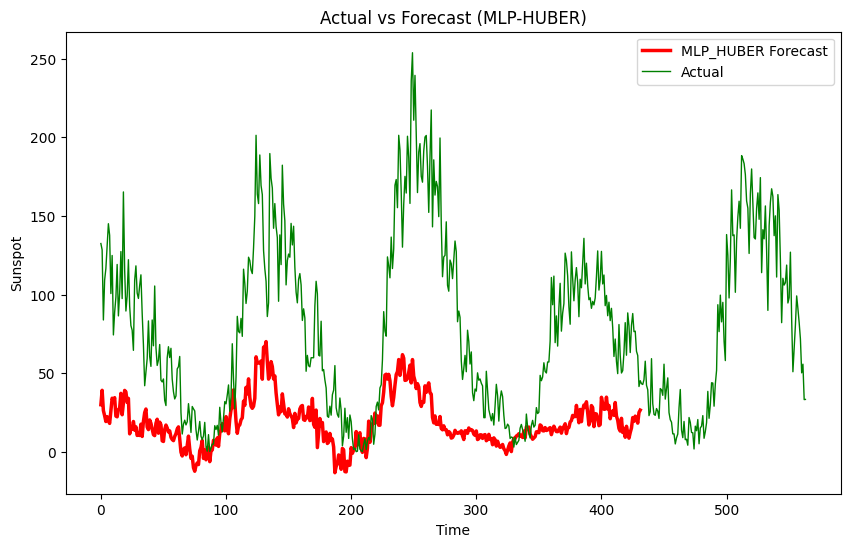


Evaluation Metrics
MSE   : 6059.188473194383
RMSE  : 77.84078926369119
NRMSE: 0.3069431753300126
MAE   : 61.492764110936285
SMAPE : 118.79360566898148
MASE  : 4.152507846739293


In [8]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 3. HUBER LOSS (CUSTOM DEFINITION)
# =========================================================
def huber_loss(delta=1.0):
    def loss(y_true, y_pred):
        error = y_true - y_pred
        abs_error = tf.abs(error)
        quadratic = tf.minimum(abs_error, delta)
        linear = abs_error - quadratic
        return tf.reduce_mean(0.5 * tf.square(quadratic) + delta * linear)
    return loss


# =========================================================
# 4. TRAIN MODEL (HUBER LOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP with Huber loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=huber_loss(delta=cfg['huber_delta'])
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)
    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={'loss': huber_loss(cfg['huber_delta'])}
    )

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)
    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_HUBER Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-HUBER)")
    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (HUBER NAMING)
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    'huber_delta': 0.101,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_30\x_train_sunspot_full_30.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_30\y_train_sunspot_full_30.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_huber_sunspot_final_30.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_huber_sunspot_loss_history_30.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_huber_sunspot_30.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_huber_sunspot_30.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_huber_sunspot_rescaled_30.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_huber_sunspot_rescaled_30.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP with Log-Cosh loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0077 - val_loss: 0.0074
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0051 - val_loss: 0.0072
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0049 - val_loss: 0.0072
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0041 - val_loss: 0.0073
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0035 - val_loss: 0.0077
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0027 - val_loss: 0.0080
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028 - val_loss: 0.0080
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


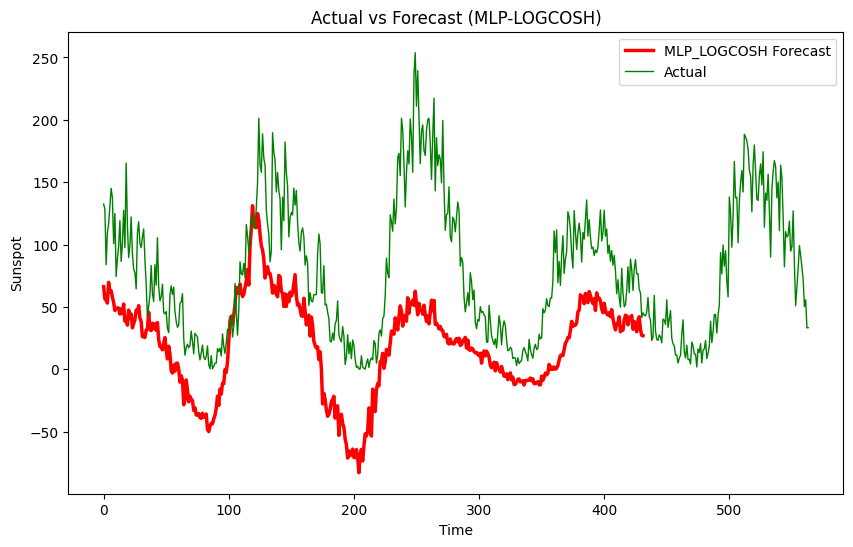


Evaluation Metrics
MSE   : 4690.236906762615
RMSE  : 68.48530431240424
NRMSE: 0.2700524617997012
MAE   : 60.20090001961858
SMAPE : 125.21459212881507
MASE  : 4.065270334266448


In [9]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 3. LOG-COSH LOSS (CUSTOM DEFINITION)
# =========================================================
def logcosh_loss(y_true, y_pred):
    return tf.reduce_mean(tf.math.log(tf.cosh(y_pred - y_true)))


# =========================================================
# 4. TRAIN MODEL (LOG-COSH LOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP with Log-Cosh loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=logcosh_loss
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={'logcosh_loss': logcosh_loss}
    )

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)
    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_LOGCOSH Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-LOGCOSH)")
    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (LOG-COSH NAMING)
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_30\x_train_sunspot_full_30.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_30\y_train_sunspot_full_30.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_logcosh_sunspot_final_30.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_logcosh_sunspot_loss_history_30.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_logcosh_sunspot_30.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_logcosh_sunspot_30.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_logcosh_sunspot_rescaled_30.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_logcosh_sunspot_rescaled_30.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP using RoBoSS loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.9678e-04 - val_loss: 3.1050e-04
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.9493e-04 - val_loss: 2.9553e-04
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.9773e-04 - val_loss: 2.9608e-04
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3905e-04 - val_loss: 2.9402e-04
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1859e-04 - val_loss: 3.0854e-04
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1958e-04 - val_loss: 3.1603e-04
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


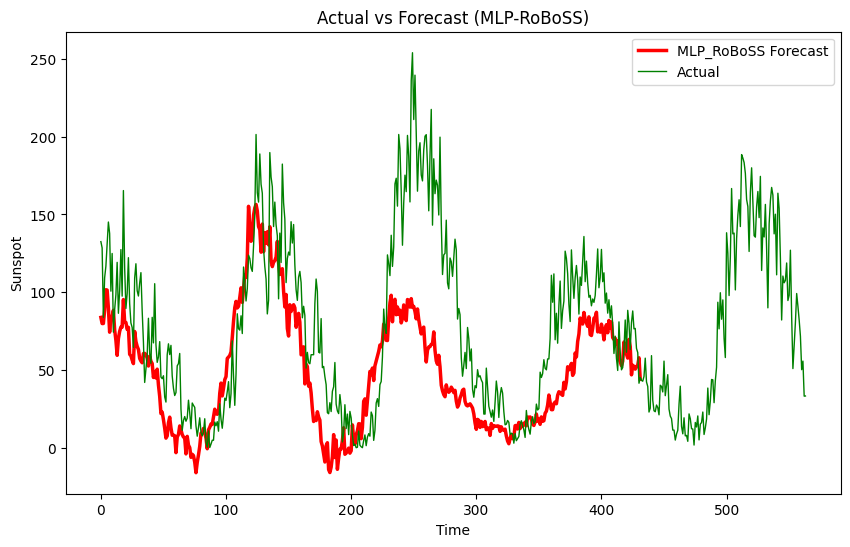


Evaluation Metrics
MSE   : 1987.0847594748107
RMSE  : 44.57672890056885
NRMSE: 0.17577574487606012
MAE   : 33.825852494211155
SMAPE : 64.00252263910849
MASE  : 2.284205628672935


In [10]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. ROBOSS LOSS
# =========================================================
def roboss_nn_loss(y_true, y_pred, a, epsilon, lam):
    u = tf.abs(y_true - y_pred)
    val = a * tf.sqrt(tf.square(u) + epsilon) - a * tf.sqrt(epsilon)
    loss_val = lam * (1 - (val + 1) * tf.exp(-val))
    return tf.reduce_mean(loss_val)


# =========================================================
# 2. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 3. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 4. TRAIN MODEL (ROBOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP using RoBoSS loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    def dynamic_roboss_loss(y_true, y_pred):
        return roboss_nn_loss(y_true, y_pred, cfg['a'], cfg['epsilon'], cfg['lam'])

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=dynamic_roboss_loss
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)

    def dynamic_roboss_loss(y_true, y_pred):
        return roboss_nn_loss(y_true, y_pred, cfg['a'], cfg['epsilon'], cfg['lam'])

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={
            'dynamic_roboss_loss': dynamic_roboss_loss,
            'roboss_nn_loss': roboss_nn_loss
        }
    )

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)

    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_RoBoSS Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-RoBoSS)")
    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    'a': 1.461,
    'epsilon': 0.043,
    'lam': 0.104,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_30\x_train_sunspot_full_30.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_30\y_train_sunspot_full_30.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV (FOR INVERSE SCALING + PLOT)
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_robos_sunspot_final_30.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_robos_daily_sunspot_loss_history_30.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_robos_sunspot_30.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_robos_sunspot_30.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_robos_sunspot_rescaled_30.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_robos_sunspot_rescaled_30.csv"
}




# =========================================================
# 10. RUN COMPLETE PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP with Cauchy loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0024 - val_loss: 0.0020
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0018 - val_loss: 0.0020
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0018 - val_loss: 0.0020
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0018 - val_loss: 0.0020
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0017 - val_loss: 0.0020
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0018 - val_loss: 0.0020
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


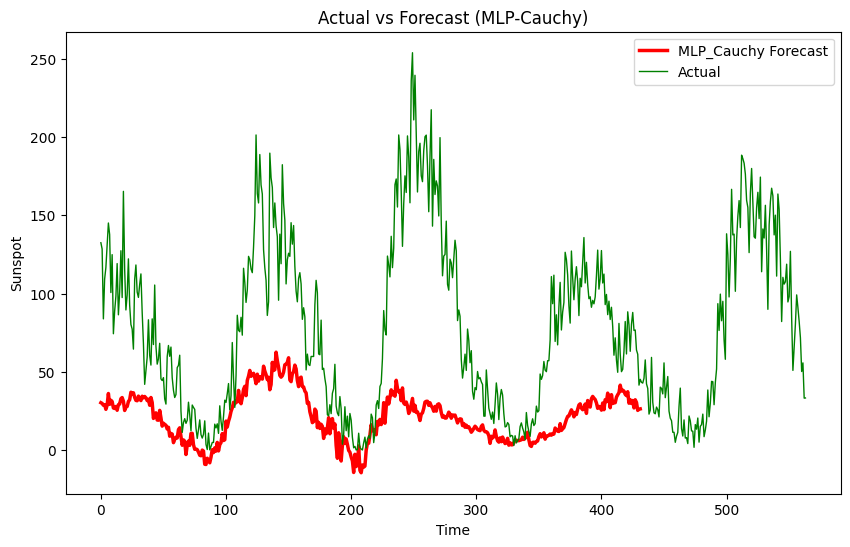


Evaluation Metrics
MSE   : 5663.044157411556
RMSE  : 75.25320031341893
NRMSE : 0.2967397488699484
MAE   : 58.895537396881636
SMAPE : 110.78133499609578
MASE  : 3.977121287592007


In [11]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):

    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x,
        y,
        test_size=validation_split,
        random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices(
        (x_train, y_train)
    ).shuffle(
        len(x_train)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    val_data = tf.data.Dataset.from_tensor_slices(
        (x_val, y_val)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():

    seq_size = 132

    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])

    return model


# =========================================================
# 3. CAUCHY LOSS
# =========================================================
def cauchy_loss(c=1.0):

    def loss(y_true, y_pred):

        error = y_true - y_pred

        loss_value = (
            (c ** 2) / 2.0
        ) * tf.math.log(
            1.0 + tf.square(error) / (c ** 2)
        )

        return tf.reduce_mean(loss_value)

    return loss


# =========================================================
# 4. TRAIN MODEL (CAUCHY LOSS)
# =========================================================
def train_model(cfg):

    print("\nTraining MLP with Cauchy loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            cfg['learning_rate'],
            amsgrad=True
        ),
        loss=cauchy_loss(
            c=cfg['cauchy_c']
        )
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(
        cfg['model_path']
    )

    pd.DataFrame(
        history.history
    ).to_csv(
        cfg['loss_path'],
        index=False
    )

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):

    print("Generating forecasts")

    x_test = np.load(
        cfg['x_test_path']
    ).reshape(-1, 132, 1)

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={
            'loss': cauchy_loss(
                cfg['cauchy_c']
            )
        }
    )

    y_hat = model.predict(x_test)

    np.save(
        cfg['forecast_npy'],
        y_hat
    )

    np.savetxt(
        cfg['forecast_csv'],
        y_hat,
        delimiter=','
    )


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):

    df_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_hat = pd.read_csv(
        cfg['forecast_csv'],
        header=None
    ).values.flatten()

    scaler = MinMaxScaler()

    inverse_preds = []

    for i in range(
        len(df_actual) - 132
    ):

        window = np.array(
            df_actual.iloc[i:i+132]
        ).reshape(-1, 1)

        scaler.fit(window)

        inverse_preds.append(
            scaler.inverse_transform(
                [[y_hat[i]]]
            )[0][0]
        )

    inverse_preds = np.array(
        inverse_preds
    )

    np.save(
        cfg['forecast_rescaled_npy'],
        inverse_preds
    )

    np.savetxt(
        cfg['forecast_rescaled_csv'],
        inverse_preds,
        delimiter=','
    )


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):

    y_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_pred = pd.read_csv(
        cfg['forecast_rescaled_csv'],
        header=None
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        y_pred,
        label="MLP_Cauchy Forecast",
        color='red',
        linewidth=2.5
    )

    plt.plot(
        y_actual,
        label="Actual",
        color='green',
        linewidth=1
    )

    plt.xlabel("Time")
    plt.ylabel("Sunspot")

    plt.title(
        "Actual vs Forecast (MLP-Cauchy)"
    )

    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):

    return np.mean(
        200 * np.abs(yhat - y) /
        (np.abs(y) + np.abs(yhat))
    )


def mase(y, yhat):

    return np.mean(
        np.abs(y - yhat)
    ) / np.mean(
        np.abs(y[1:] - y[:-1])
    )


def compute_metrics(cfg):

    y_test = np.load(
        cfg['y_test_npy']
    )

    y_pred = np.load(
        cfg['forecast_rescaled_npy']
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    nrmse = rmse / (
        np.max(y_test) -
        np.min(y_test)
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    print("\nEvaluation Metrics")

    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE :", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (CAUCHY NAMING)
# =========================================================
cfg = {

    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # Cauchy parameter
    'cauchy_c': 0.101,

    # TRAIN / TEST DATA
    'x_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_30\x_train_sunspot_full_30.npy",

    'y_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_30\y_train_sunspot_full_30.npy",

    'x_test_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",

    'y_test_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_cauchy_sunspot_final_30.h5",

    'loss_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_cauchy_sunspot_loss_history_30.csv",

    # FORECASTS
    'forecast_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_cauchy_sunspot_30.npy",

    'forecast_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_cauchy_sunspot_30.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_cauchy_sunspot_rescaled_30.npy",

    'forecast_rescaled_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_cauchy_sunspot_rescaled_30.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)


Training MLP with Tukey's Biweight loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 8.2285e-04 - val_loss: 5.4589e-04
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.8089e-04 - val_loss: 4.8902e-04
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.4200e-04 - val_loss: 4.7406e-04
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.9436e-04 - val_loss: 4.7797e-04
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.1700e-04 - val_loss: 4.7938e-04
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.8936e-04 - val_loss: 4.7466e-04
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


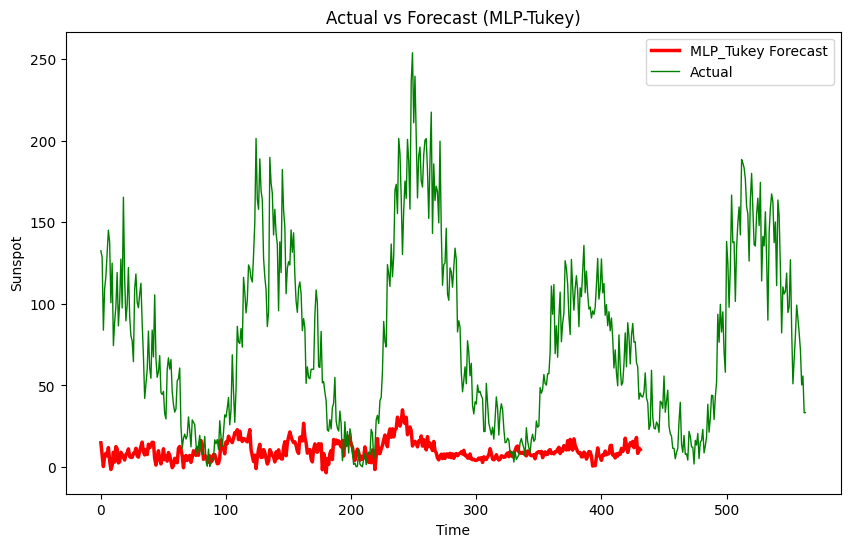


Evaluation Metrics
MSE   : 8086.591527554353
RMSE  : 89.92547763317332
NRMSE : 0.35459573199200833
MAE   : 71.00129554208445
SMAPE : 138.20971353068722
MASE  : 4.794603741267277


In [12]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):

    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x,
        y,
        test_size=validation_split,
        random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices(
        (x_train, y_train)
    ).shuffle(
        len(x_train)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    val_data = tf.data.Dataset.from_tensor_slices(
        (x_val, y_val)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():

    seq_size = 132

    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])

    return model


# =========================================================
# 3. TUKEY'S BIWEIGHT LOSS
# =========================================================
def tukey_biweight_loss(c=1.0):

    def loss(y_true, y_pred):

        error = y_true - y_pred

        abs_error = tf.abs(error)

        # Region where |r| <= c
        inside = abs_error <= c

        # Tukey biweight expression
        scaled_error = error / c

        inside_loss = (
            (c ** 2) / 6.0
        ) * (
            1.0 -
            tf.pow(
                1.0 - tf.square(scaled_error),
                3
            )
        )

        # Constant loss for |r| > c
        outside_loss = (
            (c ** 2) / 6.0
        ) * tf.ones_like(error)

        loss_value = tf.where(
            inside,
            inside_loss,
            outside_loss
        )

        return tf.reduce_mean(loss_value)

    return loss


# =========================================================
# 4. TRAIN MODEL (TUKEY'S BIWEIGHT LOSS)
# =========================================================
def train_model(cfg):

    print("\nTraining MLP with Tukey's Biweight loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            cfg['learning_rate'],
            amsgrad=True
        ),
        loss=tukey_biweight_loss(
            c=cfg['tukey_c']
        )
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(
        cfg['model_path']
    )

    pd.DataFrame(
        history.history
    ).to_csv(
        cfg['loss_path'],
        index=False
    )

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):

    print("Generating forecasts")

    x_test = np.load(
        cfg['x_test_path']
    ).reshape(-1, 132, 1)

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={
            'loss': tukey_biweight_loss(
                cfg['tukey_c']
            )
        }
    )

    y_hat = model.predict(x_test)

    np.save(
        cfg['forecast_npy'],
        y_hat
    )

    np.savetxt(
        cfg['forecast_csv'],
        y_hat,
        delimiter=','
    )


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):

    df_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_hat = pd.read_csv(
        cfg['forecast_csv'],
        header=None
    ).values.flatten()

    scaler = MinMaxScaler()

    inverse_preds = []

    for i in range(
        len(df_actual) - 132
    ):

        window = np.array(
            df_actual.iloc[i:i+132]
        ).reshape(-1, 1)

        scaler.fit(window)

        inverse_preds.append(
            scaler.inverse_transform(
                [[y_hat[i]]]
            )[0][0]
        )

    inverse_preds = np.array(
        inverse_preds
    )

    np.save(
        cfg['forecast_rescaled_npy'],
        inverse_preds
    )

    np.savetxt(
        cfg['forecast_rescaled_csv'],
        inverse_preds,
        delimiter=','
    )


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):

    y_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_pred = pd.read_csv(
        cfg['forecast_rescaled_csv'],
        header=None
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        y_pred,
        label="MLP_Tukey Forecast",
        color='red',
        linewidth=2.5
    )

    plt.plot(
        y_actual,
        label="Actual",
        color='green',
        linewidth=1
    )

    plt.xlabel("Time")
    plt.ylabel("Sunspot")

    plt.title(
        "Actual vs Forecast (MLP-Tukey)"
    )

    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):

    return np.mean(
        200 * np.abs(yhat - y) /
        (np.abs(y) + np.abs(yhat))
    )


def mase(y, yhat):

    return np.mean(
        np.abs(y - yhat)
    ) / np.mean(
        np.abs(y[1:] - y[:-1])
    )


def compute_metrics(cfg):

    y_test = np.load(
        cfg['y_test_npy']
    )

    y_pred = np.load(
        cfg['forecast_rescaled_npy']
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    nrmse = rmse / (
        np.max(y_test) -
        np.min(y_test)
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    print("\nEvaluation Metrics")

    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE :", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (TUKEY NAMING)
# =========================================================
cfg = {

    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # Tukey's Biweight parameter
    'tukey_c': 0.100,

    # TRAIN / TEST DATA
    'x_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_30\x_train_sunspot_full_30.npy",

    'y_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_30\y_train_sunspot_full_30.npy",

    'x_test_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",

    'y_test_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_tukey_sunspot_final_30.h5",

    'loss_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_tukey_sunspot_loss_history_30.csv",

    # FORECASTS
    'forecast_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_tukey_sunspot_30.npy",

    'forecast_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_tukey_sunspot_30.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_tukey_sunspot_rescaled_30.npy",

    'forecast_rescaled_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_tukey_sunspot_rescaled_30.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)


Training MLP with HawkEye loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.9503e-04 - val_loss: 5.5237e-04
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.0124e-04 - val_loss: 5.3545e-04
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.2364e-04 - val_loss: 5.3953e-04
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6193e-04 - val_loss: 5.5904e-04
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.5251e-04 - val_loss: 5.5130e-04
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.1225e-04 - val_loss: 5.9401e-04
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


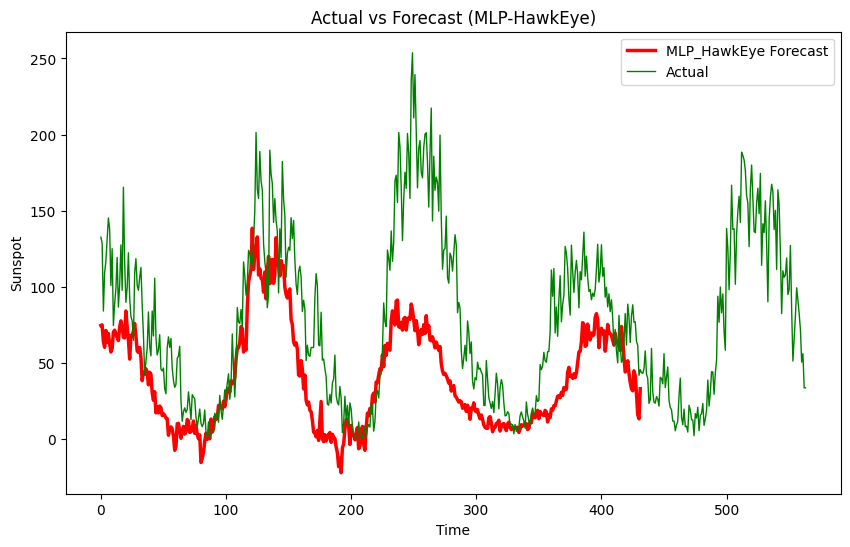


Evaluation Metrics
MSE   : 2902.003422743741
RMSE  : 53.87024617303824
NRMSE : 0.21242210636056086
MAE   : 40.91423088411705
SMAPE : 80.27416614605708
MASE  : 2.76287246550011


In [13]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):

    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x,
        y,
        test_size=validation_split,
        random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices(
        (x_train, y_train)
    ).shuffle(
        len(x_train)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    val_data = tf.data.Dataset.from_tensor_slices(
        (x_val, y_val)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():

    seq_size = 132

    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])

    return model


# =========================================================
# 3. HAWKEYE LOSS
# =========================================================
def hawkeye_loss(a=1.0, epsilon=0.02, lam=1.0):

    def loss(y_true, y_pred):

        # Residual
        r = y_true - y_pred

        # -------------------------------------------------
        # Left region: r <= -epsilon
        # -------------------------------------------------
        left_loss = lam * (
            1.0
            - (
                -a * (r + epsilon) + 1.0
            )
            * tf.exp(
                a * (r + epsilon)
            )
        )

        # -------------------------------------------------
        # Middle region: -epsilon < r < epsilon
        # -------------------------------------------------
        middle_loss = tf.zeros_like(r)

        # -------------------------------------------------
        # Right region: r >= epsilon
        # -------------------------------------------------
        right_loss = lam * (
            1.0
            - (
                a * (r - epsilon) + 1.0
            )
            * tf.exp(
                -a * (r - epsilon)
            )
        )

        # -------------------------------------------------
        # Piecewise HawkEye loss
        # -------------------------------------------------
        loss_value = tf.where(
            r <= -epsilon,
            left_loss,
            tf.where(
                r >= epsilon,
                right_loss,
                middle_loss
            )
        )

        return tf.reduce_mean(loss_value)

    return loss


# =========================================================
# 4. TRAIN MODEL (HAWKEYE LOSS)
# =========================================================
def train_model(cfg):

    print("\nTraining MLP with HawkEye loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            cfg['learning_rate'],
            amsgrad=True
        ),
        loss=hawkeye_loss(
            a=cfg['hawkeye_a'],
            epsilon=cfg['hawkeye_epsilon'],
            lam=cfg['hawkeye_lam']
        )
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(
        cfg['model_path']
    )

    pd.DataFrame(
        history.history
    ).to_csv(
        cfg['loss_path'],
        index=False
    )

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):

    print("Generating forecasts")

    x_test = np.load(
        cfg['x_test_path']
    ).reshape(-1, 132, 1)

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={
            'loss': hawkeye_loss(
                a=cfg['hawkeye_a'],
                epsilon=cfg['hawkeye_epsilon'],
                lam=cfg['hawkeye_lam']
            )
        }
    )

    y_hat = model.predict(x_test)

    np.save(
        cfg['forecast_npy'],
        y_hat
    )

    np.savetxt(
        cfg['forecast_csv'],
        y_hat,
        delimiter=','
    )


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):

    df_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_hat = pd.read_csv(
        cfg['forecast_csv'],
        header=None
    ).values.flatten()

    scaler = MinMaxScaler()

    inverse_preds = []

    for i in range(
        len(df_actual) - 132
    ):

        window = np.array(
            df_actual.iloc[i:i+132]
        ).reshape(-1, 1)

        scaler.fit(window)

        inverse_preds.append(
            scaler.inverse_transform(
                [[y_hat[i]]]
            )[0][0]
        )

    inverse_preds = np.array(
        inverse_preds
    )

    np.save(
        cfg['forecast_rescaled_npy'],
        inverse_preds
    )

    np.savetxt(
        cfg['forecast_rescaled_csv'],
        inverse_preds,
        delimiter=','
    )


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):

    y_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_pred = pd.read_csv(
        cfg['forecast_rescaled_csv'],
        header=None
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        y_pred,
        label="MLP_HawkEye Forecast",
        color='red',
        linewidth=2.5
    )

    plt.plot(
        y_actual,
        label="Actual",
        color='green',
        linewidth=1
    )

    plt.xlabel("Time")
    plt.ylabel("Sunspot")

    plt.title(
        "Actual vs Forecast (MLP-HawkEye)"
    )

    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):

    return np.mean(
        200 * np.abs(yhat - y) /
        (np.abs(y) + np.abs(yhat))
    )


def mase(y, yhat):

    return np.mean(
        np.abs(y - yhat)
    ) / np.mean(
        np.abs(y[1:] - y[:-1])
    )


def compute_metrics(cfg):

    y_test = np.load(
        cfg['y_test_npy']
    )

    y_pred = np.load(
        cfg['forecast_rescaled_npy']
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    nrmse = rmse / (
        np.max(y_test) -
        np.min(y_test)
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    print("\nEvaluation Metrics")

    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE :", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (HAWKEYE NAMING)
# =========================================================
cfg = {

    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # -----------------------------------------------------
    # HAWKEYE PARAMETERS
    # -----------------------------------------------------
    'hawkeye_a': 1.062,
    'hawkeye_epsilon': 0.023,
    'hawkeye_lam': 0.102,

    # -----------------------------------------------------
    # TRAIN / TEST DATA
    # -----------------------------------------------------
    'x_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_30\x_train_sunspot_full_30.npy",

    'y_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_30\y_train_sunspot_full_30.npy",

    'x_test_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",

    'y_test_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # -----------------------------------------------------
    # RAW TEST CSV
    # -----------------------------------------------------
    'actual_test_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # -----------------------------------------------------
    # MODEL & LOGS
    # -----------------------------------------------------
    'model_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_hawkeye_sunspot_final_30.h5",

    'loss_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_hawkeye_sunspot_loss_history_30.csv",

    # -----------------------------------------------------
    # FORECASTS
    # -----------------------------------------------------
    'forecast_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_hawkeye_sunspot_30.npy",

    'forecast_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_hawkeye_sunspot_30.csv",

    # -----------------------------------------------------
    # RESCALED FORECASTS
    # -----------------------------------------------------
    'forecast_rescaled_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_hawkeye_sunspot_rescaled_30.npy",

    'forecast_rescaled_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_hawkeye_sunspot_rescaled_30.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)